In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

# ----------------------------------------------------------------
# 0. 로컬 환경 설정 안내 (스크립트 실행 전 터미널에서 수행)
# ----------------------------------------------------------------
#
# 1. Python 3.8 이상 설치되어 있는지 확인
#
# 2. 필요한 라이브러리 설치 (터미널/명령 프롬프트에서 실행):
#    pip install easyocr opencv-python-headless Pillow matplotlib torch torchvision torchaudio transformers accelerate bitsandbytes sentencepiece
#
# 3. NVIDIA GPU 사용 시 (권장):
#    - NVIDIA 드라이버 최신 버전 설치
#    - CUDA Toolkit 설치 (PyTorch와 호환되는 버전)
#    - cuDNN 설치 (PyTorch와 호환되는 버전)
#    - PyTorch GPU 버전 설치 (예: CUDA 11.8 사용 시, PyTorch 공식 웹사이트에서 맞는 명령어 확인)
#      pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
#    CPU만 사용 시에는 일반 PyTorch 설치로도 동작하나, Gemma 모델 속도가 매우 느립니다.
#
# 4. Hugging Face Hub 로그인 (Gemma 모델 접근 시 필요할 수 있음):
#    터미널에서 다음 명령어 실행 후 토큰 입력 (최초 1회):
#    huggingface-cli login
#    (Gemma 3 모델의 경우, 해당 모델 페이지에서 라이선스 동의도 필요합니다.)
#
# ----------------------------------------------------------------

# ----------------------------------------------------------------
# 0. 캐시 디렉토리 변경 (모든 Hugging Face/Transformers 임포트 전에 설정)
# ----------------------------------------------------------------
# 새로운 캐시 디렉토리 설정 (D 드라이브 예시)
import os
# 캐시 디렉토리 설정 (스크립트 최상단에!)
new_cache_dir_base = r"D:\김가람의 공부\십라\huggingface_cache"
hub_cache_dir = os.path.join(new_cache_dir_base, "hub")
os.makedirs(hub_cache_dir, exist_ok=True)
os.environ['HF_HOME'] = new_cache_dir_base
os.environ['HUGGINGFACE_HUB_CACHE'] = hub_cache_dir
os.environ['TRANSFORMERS_CACHE'] = hub_cache_dir
print(f"Cache dir set to: {hub_cache_dir}")

import torch
from transformers import AutoTokenizer, Gemma3ForConditionalGeneration

gemma_model_id = "google/gemma-3-4b-it"
print(f"Attempting to load tokenizer for: {gemma_model_id}")


# ----------------------------------------------------------------
# 1. 라이브러리 임포트
# ----------------------------------------------------------------


import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import easyocr
import numpy as np
import matplotlib.patches as patches
import cv2
from PIL import Image
import re
import json

from dotenv import load_dotenv
load_dotenv("garakey.env")

# Ensure transformers is up to date and import AutoModelForCausalLM for Gemma models
try:
    from transformers import AutoTokenizer, AutoProcessor, AutoModelForCausalLM, Gemma3ForConditionalGeneration
except ImportError:
    # Install/upgrade transformers and retry import
    import sys
    # Jupyter magic for pip install
    if 'google.colab' in sys.modules or 'ipykernel' in sys.modules:
        # Only run in notebook environments
        try:
            get_ipython().run_line_magic('pip', 'install --upgrade "transformers>=4.40.0"')
        except NameError:
            # If get_ipython is not defined, use subprocess instead
            import subprocess
            subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "transformers>=4.40.0"])
    else:
        raise
    from transformers import AutoTokenizer, AutoProcessor, AutoModelForCausalLM, Gemma3ForConditionalGeneration

# Matplotlib 한글 폰트 설정 (Windows 기준)
try:
    plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 기본 한글 폰트
    print("'Malgun Gothic' 폰트 설정 시도.")
except RuntimeError:
    try:
        plt.rcParams['font.family'] = 'NanumGothic' # Nanum 폰트가 설치되어 있다면
        print("'NanumGothic' 폰트 설정 시도.")
    except RuntimeError:
        print("경고: 'Malgun Gothic' 또는 'NanumGothic' 폰트를 찾을 수 없습니다. Matplotlib 시각화 시 한글이 깨질 수 있습니다.")
        print("다른 한글 폰트를 시스템에 설치하거나, 설치된 폰트명을 사용하세요.")
plt.rcParams['axes.unicode_minus'] = False

# ----------------------------------------------------------------
# 2. 이미지 불러오기 및 경로 설정
# ----------------------------------------------------------------
# !!!! 중요: 아래 base_folder_path와 image_file_name을 실제 환경에 맞게 수정해주세요!!!!
base_folder_path = r"D:\김가람의 공부\십라\-\새 폴더\사진" # 사용자 제공 경로 (raw string으로 처리)
image_file_name = "영수증 이미지 3.jpg" # 여기에 실제 영수증 이미지 파일명을 입력하세요.

image_path = os.path.join(base_folder_path, image_file_name)

if not os.path.exists(image_path):
    print(f"에러: 이미지 파일을 찾을 수 없습니다. 경로를 확인해주세요: {image_path}")
    raise FileNotFoundError(f"이미지 파일을 찾을 수 없습니다: {image_path}")

try:
    receipt_image_pil = Image.open(image_path)
    print(f"이미지 로드 완료: {receipt_image_pil.format}, {receipt_image_pil.size}, {receipt_image_pil.mode} ({image_path})")
except Exception as e:
    print(f"이미지 파일 로드 중 오류 발생: {e} ({image_path})")
    raise

Cache dir set to: D:\김가람의 공부\십라\huggingface_cache\hub
Attempting to load tokenizer for: google/gemma-3-4b-it
'Malgun Gothic' 폰트 설정 시도.
이미지 로드 완료: JPEG, (463, 1816), RGB (D:\김가람의 공부\십라\-\새 폴더\사진\영수증 이미지 3.jpg)


In [10]:

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU count: {torch.cuda.device_count()}")
    print(f"GPU name: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.2.2+cu118
CUDA available: True
CUDA version: 11.8
GPU count: 1
GPU name: NVIDIA GeForce RTX 4070 SUPER


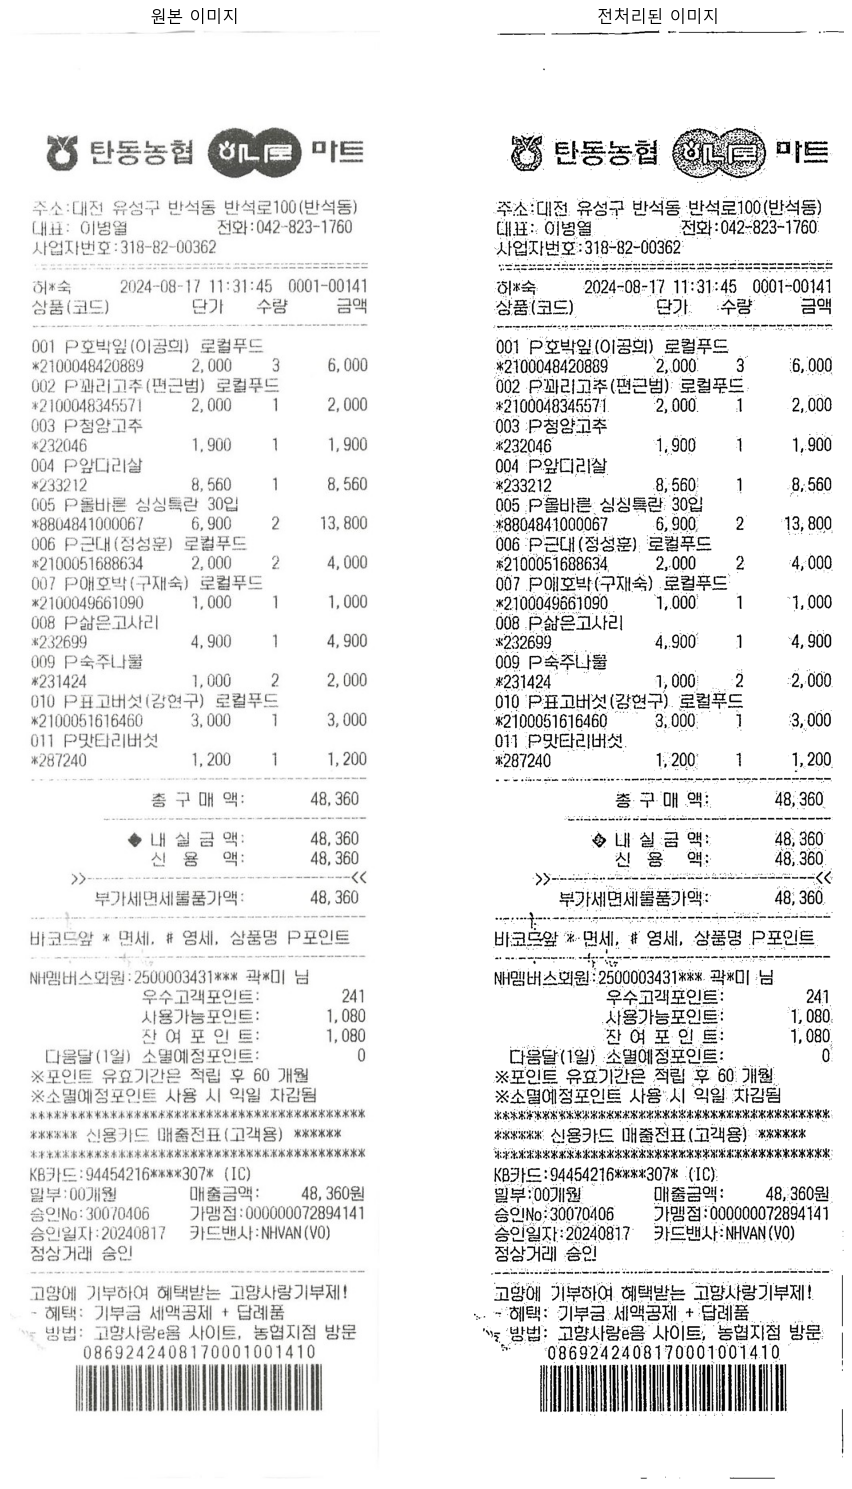

이미지 전처리 완료 및 시각화가 표시되었습니다.

EasyOCR 리더 초기화 중...
EasyOCR GPU 사용 설정: True
EasyOCR 텍스트 인식 시작...
EasyOCR 텍스트 인식 완료.

=== OCR 결과로 그룹화된 라인별 텍스트 (Gemma 입력용) ===
라인 1: 탄동농협 해네) 마트
라인 2: 주소: 대전 유성구 반석동_반석로기이(반석동
라인 3: 전화: 042-823-1760
라인 4: 사업자번호: 318-82-00362
라인 5: 2024-08-17 11:31:45 0001-00141
라인 6: 상품(코드) 단가: 수량: 금액
라인 7: 001 P호박임(이공의) 로럴무드
라인 8: *2100048420889 '2000' 3 '6,000
라인 9: 002 P 과리고추 (편근범): 로럴푸드
라인 10: *2100048345571 2,000 1 2,000
라인 11: 003 P청양고추
라인 12: *232046 1,900 1 1,900
라인 13: 004 P앞디리살
라인 14: '*233212 8,560: 1 8,560
라인 15: 005 P올바른 심싱특관 30입
라인 16: *8804841000067 6,g00 2 '13,800
라인 17: 006 P근대(정성문) 로어무드
라인 18: *2100057688634 2,000 2 '4,000
라인 19: 007 P애호박 (구재숙) 로럴무드
라인 20: *2100049661090 1,000 1 1,000
라인 21: 008 P삶은고사리
라인 22: *232699 4,900 1 '4,900
라인 23: 009 P숙주나물
라인 24: *231424 1;0003 2 2,000
라인 25: 010 P표고버섯 (강현구) 로럴무드
라인 26: *2100051616460 3,000: 1 3,000
라인 27: 011 P맛리버섯
라인 28: '#287240 1;200' 1,200
라인 29: 총 구 매 액: 48,.360
라인 30: :i:;오: :: : '
라인 31: 내I 실 금 액: 48; 360'
라

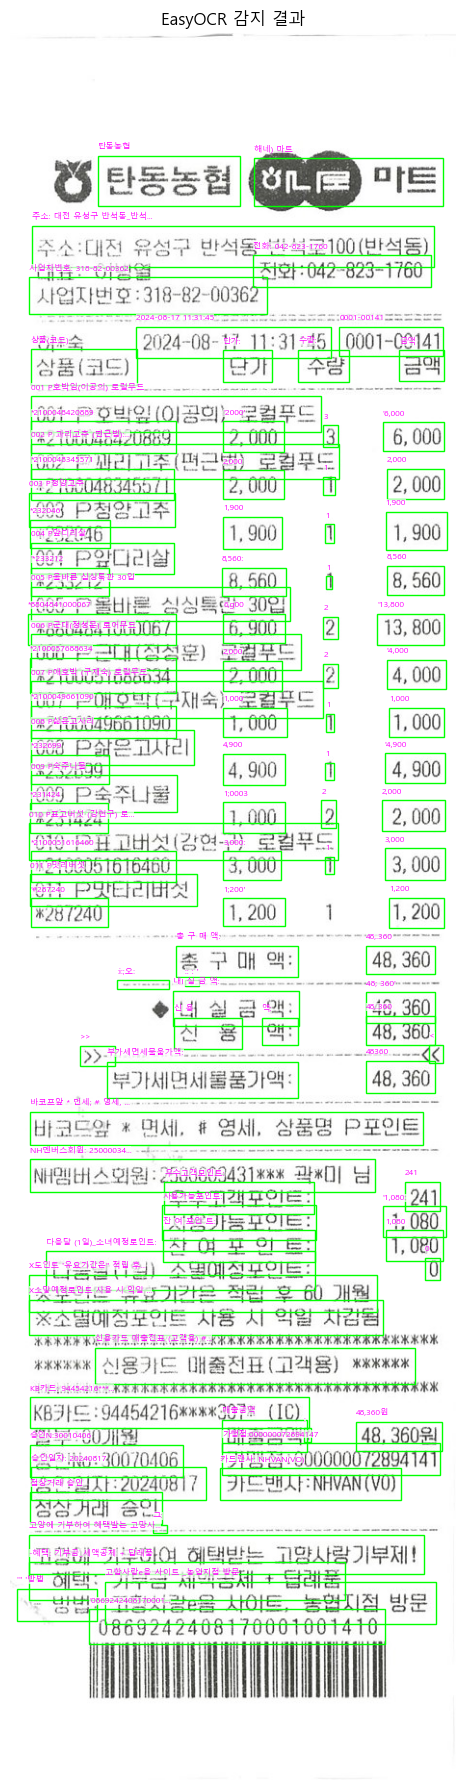

EasyOCR 감지 결과 시각화가 표시되었습니다.

=== Gemma 모델 로딩 및 실행 준비 ===
'google/gemma-3-4b-it' 모델 로딩 시도... (첫 실행 시 다운로드로 오래 걸릴 수 있습니다)
NVIDIA GPU 감지됨. Gemma를 cuda에서 torch.bfloat16로 로드 시도.


The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.
Loading checkpoint shards: 100%|██████████| 2/2 [01:50<00:00, 55.21s/it]
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


'google/gemma-3-4b-it' 모델 로드 완료. 실행 장치: cuda:0

=== Gemma 모델에 전달할 프롬프트 구성 (수정됨) ===

=== Gemma 모델로 JSON 생성 시작... ===

=== Gemma 모델이 생성한 JSON 텍스트 (추정) ===
```json
{
  "store_name": "탄동농협 해네) 마트",
  "address": "대전 유성구 반석동_반석로기이(반석동",
  "business_number": "318-82-00362",
  "phone": "042-823-1760",
  "date": "2024-08-17 11:31:45",
  "total_price": 48360,
  "items": [
    {
      "name": "P호박임(이공의) 로럴무드",
      "unit_price": "2000",
      "quantity": "3",
      "total": "6000"
    },
    {
      "name": "P 과리고추 (편근범): 로럴푸드",
      "unit_price": "2000",
      "quantity": "1",
      "total": "2000"
    },
    {
      "name": "P청양고추",
      "unit_price": "1900",
      "quantity": "1",
      "total": "1900"
    },
    {
      "name": "P앞디리살",
      "unit_price": "8560",
      "quantity": "1",
      "total": "8560"
    },
    {
      "name": "P올바른 심싱특관 30입",
      "unit_price": "6000",
      "quantity": "2",
      "total": "13800"
    },
    {
      "name": "P근대(정성문) 로어무드",
      "unit_price": "

In [ ]:
# ----------------------------------------------------------------
# 3. 이미지 전처리 함수 정의
# ----------------------------------------------------------------
def preprocess_receipt_image(pil_image):
    img_cv = cv2.cvtColor(np.array(pil_image), cv2.COLOR_RGB2BGR)
    img_cv = cv2.resize(img_cv, None, fx=2.0, fy=2.0, interpolation=cv2.INTER_CUBIC)
    gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)
    blurred = gray 
    binary = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY, 15, 4)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2,2))
    processed_binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)
    return Image.fromarray(processed_binary)

# ----------------------------------------------------------------
# 4. 이미지 전처리 실행 및 결과 비교 시각화
# ----------------------------------------------------------------
processed_pil_image = preprocess_receipt_image(receipt_image_pil)

plt.figure(figsize=(10, 15)) 
plt.subplot(1, 2, 1); plt.title("원본 이미지"); plt.imshow(receipt_image_pil); plt.axis('off')
plt.subplot(1, 2, 2); plt.title("전처리된 이미지"); plt.imshow(processed_pil_image, cmap='gray'); plt.axis('off')
plt.tight_layout(); plt.show()
print("이미지 전처리 완료 및 시각화가 표시되었습니다.")


# ----------------------------------------------------------------
# 5. EasyOCR 실행 (전처리된 이미지 사용)
# ----------------------------------------------------------------
print("\nEasyOCR 리더 초기화 중...")
use_gpu_easyocr = torch.cuda.is_available()
print(f"EasyOCR GPU 사용 설정: {use_gpu_easyocr}")
try:
    reader = easyocr.Reader(['ko', 'en'], gpu=use_gpu_easyocr) 
except Exception as e:
    print(f"EasyOCR 리더 초기화 중 오류: {e}")
    if use_gpu_easyocr:
        print("GPU 사용 중 오류 발생. CPU로 재시도합니다...")
        reader = easyocr.Reader(['ko', 'en'], gpu=False)
    else:
        raise 

print("EasyOCR 텍스트 인식 시작...")
ocr_result_on_processed = reader.readtext(
    np.array(processed_pil_image), 
    detail=1, paragraph=False, batch_size=8, 
    text_threshold=0.4, link_threshold=0.2, low_text=0.3,
    width_ths=0.5, height_ths=0.5,
    decoder='beamsearch', mag_ratio=1.5
)
print("EasyOCR 텍스트 인식 완료.")

# ----------------------------------------------------------------
# 6. OCR 결과 추출 및 텍스트 후처리
# ----------------------------------------------------------------
extracted_texts = []
extracted_boxes_scaled_to_original = []
scale_factor_from_preprocessing = 0.5

for detection in ocr_result_on_processed:
    box_on_processed, text, score = detection
    if score > 0.1: 
        extracted_texts.append(text)
        x_coords = [point[0] for point in box_on_processed]
        y_coords = [point[1] for point in box_on_processed]
        x_min_orig = min(x_coords) * scale_factor_from_preprocessing
        y_min_orig = min(y_coords) * scale_factor_from_preprocessing
        x_max_orig = max(x_coords) * scale_factor_from_preprocessing
        y_max_orig = max(y_coords) * scale_factor_from_preprocessing
        extracted_boxes_scaled_to_original.append(
            (int(x_min_orig), int(y_min_orig), int(x_max_orig - x_min_orig), int(y_max_orig - y_min_orig))
        )

def clean_ocr_text(text):
    text = text.strip()
    text = re.sub(r'(?<=\d)O(?=\d)|(?<=\d)o(?=\d)', '0', text)
    text = re.sub(r'(?<=\d)I(?=\d)|(?<=\d)l(?=\d)', '1', text)
    text = re.sub(r'\s{2,}', ' ', text) 
    return text

cleaned_texts_for_grouping = [clean_ocr_text(text) for text in extracted_texts if text.strip()]
cleaned_boxes_for_grouping = [box for text, box in zip(extracted_texts, extracted_boxes_scaled_to_original) if text.strip()]

# ----------------------------------------------------------------
# 7. 라인별 텍스트 그룹화 (원본 이미지 좌표 기준)
# ----------------------------------------------------------------
sorted_ocr_data = sorted(zip(cleaned_texts_for_grouping, cleaned_boxes_for_grouping), key=lambda x: (x[1][1], x[1][0])) 
grouped_lines = []
current_line_elements = []
last_y_avg = -1
y_coordinate_tolerance = 12 

for text, (x_orig, y_orig, w_orig, h_orig) in sorted_ocr_data:
    if not text: continue
    current_y_avg = y_orig + h_orig / 2
    if last_y_avg == -1 or abs(current_y_avg - last_y_avg) <= y_coordinate_tolerance:
        current_line_elements.append({'text': text, 'x': x_orig})
    else:
        if current_line_elements:
            current_line_elements.sort(key=lambda item: item['x'])
            grouped_lines.append({'line_text': " ".join([elem['text'] for elem in current_line_elements])})
        current_line_elements = [{'text': text, 'x': x_orig}]
    last_y_avg = current_y_avg
if current_line_elements:
    current_line_elements.sort(key=lambda item: item['x'])
    grouped_lines.append({'line_text': " ".join([elem['text'] for elem in current_line_elements])})

print("\n=== OCR 결과로 그룹화된 라인별 텍스트 (Gemma 입력용) ===")
ocr_input_for_gemma_list = []
if grouped_lines:
    for i, line_info in enumerate(grouped_lines):
        print(f"라인 {i+1}: {line_info['line_text']}")
        ocr_input_for_gemma_list.append(line_info['line_text'])
    ocr_full_text_for_gemma = "\n".join(ocr_input_for_gemma_list)
else:
    print("OCR 결과에서 그룹화된 라인이 없습니다. OCR 결과나 파라미터를 확인해주세요.")
    ocr_full_text_for_gemma = "" 

# ----------------------------------------------------------------
# 8. OCR 결과 시각화 (EasyOCR 감지 결과)
# ----------------------------------------------------------------
plt.figure(figsize=(12, 18)) 
plt.imshow(receipt_image_pil)
for (x,y,w,h), text in zip(cleaned_boxes_for_grouping, cleaned_texts_for_grouping): 
    if not text: continue
    rect = patches.Rectangle((x,y),w,h, linewidth=1, edgecolor="lime", facecolor="none")
    plt.gca().add_patch(rect)
    display_text = text if len(text) < 20 else text[:17] + "..."
    plt.text(x, y-7, display_text, color="magenta", fontsize=6, 
             bbox=dict(facecolor="white", alpha=0.7, pad=0, edgecolor='none'), fontweight='normal')
plt.title("EasyOCR 감지 결과")
plt.axis('off'); plt.tight_layout(); plt.show()
print("EasyOCR 감지 결과 시각화가 표시되었습니다.")


# ----------------------------------------------------------------
# 9. Gemma를 이용한 JSON 구조화 및 totalPrice 추출
# ----------------------------------------------------------------
parsed_json_from_gemma = None
if ocr_full_text_for_gemma: 
    print("\n=== Gemma 모델 로딩 및 실행 준비 ===")
    
    gemma_model_id = "google/gemma-3-4b-it" # 요청하신 모델
    # gemma_model_id = "google/gemma-2b-it" # 테스트용 작은 모델 (이것도 인증 필요할 수 있음)

    gemma_tokenizer_for_text = None # 명확성을 위해 변수명 변경
    gemma_model = None

    print(f"'{gemma_model_id}' 모델 로딩 시도... (첫 실행 시 다운로드로 오래 걸릴 수 있습니다)")
    try:
        gemma_tokenizer_for_text = AutoTokenizer.from_pretrained(gemma_model_id)
        
        if torch.cuda.is_available():
            device_for_gemma = "cuda"
            dtype_for_gemma = torch.bfloat16 
            print(f"NVIDIA GPU 감지됨. Gemma를 {device_for_gemma}에서 {dtype_for_gemma}로 로드 시도.")
        else:
            device_for_gemma = "cpu"
            dtype_for_gemma = torch.float32
            print(f"NVIDIA GPU를 찾을 수 없습니다. Gemma를 CPU로 로드합니다 (매우 느릴 수 있음).")

        gemma_model = Gemma3ForConditionalGeneration.from_pretrained( # Gemma 3 모델 클래스
            gemma_model_id,
            torch_dtype=dtype_for_gemma, 
            device_map=device_for_gemma,
            load_in_4bit=True, # 극단적인 메모리 절약 (bitsandbytes 필요, 품질 저하 가능)
        )
        print(f"'{gemma_model_id}' 모델 로드 완료. 실행 장치: {gemma_model.device}")

    except Exception as e:
        print(f"Gemma 모델 로딩 중 오류: {e}")
        print(f"해결 방법 제안:")
        print(f"1. Hugging Face Hub에서 '{gemma_model_id}' 모델 페이지를 방문하여 라이선스에 동의했는지 확인하세요.")
        print(f"2. 터미널에서 'huggingface-cli login' 명령어로 미리 로그인했는지 확인하세요.")
        print(f"3. GPU 사용 시: CUDA, cuDNN, PyTorch GPU 버전이 호환되는지 확인하세요.")
        print(f"4. 메모리 부족일 수 있습니다. 더 작은 모델(예: google/gemma-2b-it)로 변경하거나, from_pretrained에 load_in_4bit=True 또는 load_in_8bit=True 옵션 사용을 고려하세요 (bitsandbytes 라이브러리 필요).")
        gemma_model = None

    if gemma_model and gemma_tokenizer_for_text:
        print("\n=== Gemma 모델에 전달할 프롬프트 구성 (수정됨) ===")
        prompt_for_gemma = f"""당신은 제공된 "OCR 결과" 텍스트에서 정보를 추출하여 지정된 JSON 형식으로 정리하는 AI 어시스턴트입니다.
가장 중요한 목표는 영수증의 **최종 결제 총액 (total_price)**을 정확하게 추출하는 것입니다.
다른 모든 정보도 중요하지만, **total_price**는 반드시 포함되어야 합니다.

**정보 추출 지침:**
*   **반드시 "OCR 결과" 텍스트에 있는 실제 데이터를 사용해야 합니다.** 없는 정보는 추측하거나 임의로 만들지 마세요.
*   존재하지 않는 정보는 빈 문자열("") 또는 JSON 형식에 따라 `null` 값으로 표시합니다.
*   숫자 값(가격, 수량 등)은 콤마(,)를 제거하고 숫자 형태의 문자열로 표현해주세요 (예: "48360").
*   날짜 및 시간은 "YYYY-MM-DD HH:MM:SS" 형식을 최우선으로 시도하고, 어려우면 OCR 결과에 인식된 그대로 제공해주세요.
*   상품 목록(items)에서 단가(unit_price), 수량(quantity), 합계(total)는 숫자 형태의 문자열로, 상품명(name)은 문자열로 추출해주세요.
*   수량이 명시되지 않은 경우 기본값으로 "1"을 사용합니다.

**요구되는 JSON 형식 예시:**
```json
{{
  "store_name": "가게 이름 (문자열)",
  "address": "가게 주소 (문자열)",
  "business_number": "사업자 번호 (문자열, 예: 123-45-67890)",
  "phone": "전화번호 (문자열, 예: 010-1234-5678)",
  "date": "거래 날짜 및 시간 (문자열, 예: 2024-08-17 11:31:45)",
  "total_price": "영수증의 최종 결제 총액 (숫자 문자열, 예: 48360)",
  "items": [
    {{
      "name": "상품명1 (문자열)",
      "unit_price": "단가1 (숫자 문자열)",
      "quantity": "수량1 (숫자 문자열, 없으면 1)",
      "total": "상품1 총액 (숫자 문자열)"
    }},
    {{
      "name": "상품명2 (문자열)",
      "unit_price": "단가2 (숫자 문자열)",
      "quantity": "수량2 (숫자 문자열)",
      "total": "상품2 총액 (숫자 문자열)"
    }}
  ]
}}
```

--- OCR 결과 시작 ---
{ocr_full_text_for_gemma}
--- OCR 결과 끝 ---

위 "OCR 결과"를 바탕으로 JSON 객체를 생성해주세요.
응답은 다른 설명 없이 순수한 JSON 객체만 포함해야 합니다.
**특히, `total_price` 필드에는 영수증에 명시된 사용자가 실제로 지불해야 하는 최종 금액을 정확히 기입해야 합니다.**

정리된 JSON:
"""
        # print("--- 프롬프트 시작 (디버깅용) ---")
        # print(prompt_for_gemma) # 프롬프트 내용 확인용
        # print("--- 프롬프트 끝 ---")

        print("\n=== Gemma 모델로 JSON 생성 시작... ===")
        try:
            inputs = gemma_tokenizer_for_text(prompt_for_gemma, return_tensors="pt", padding=True, truncation=False).to(gemma_model.device)
            
            outputs = gemma_model.generate(
                inputs.input_ids, 
                attention_mask=inputs.attention_mask, 
                max_new_tokens=2048, 
                temperature=0.0,    
                do_sample=False     
            )
            generated_text_full = gemma_tokenizer_for_text.decode(outputs[0], skip_special_tokens=True)
            
            json_output_marker = "정리된 JSON:"
            generated_json_text = ""
            if json_output_marker in generated_text_full: 
                generated_json_text = generated_text_full.split(json_output_marker)[-1].strip()
            else:
                match_json_block = re.search(r"```json\s*([\s\S]*?)\s*```", generated_text_full, re.DOTALL)
                if match_json_block: 
                    generated_json_text = match_json_block.group(1).strip()
                else:
                    start_brace = generated_text_full.rfind("{")
                    end_brace = -1
                    if start_brace != -1:
                        open_braces = 0
                        for i in range(start_brace, len(generated_text_full)):
                            if generated_text_full[i] == '{{': open_braces += 1
                            elif generated_text_full[i] == '}}':
                                open_braces -= 1
                                if open_braces == 0: end_brace = i; break
                    if start_brace != -1 and end_brace != -1 and start_brace < end_brace: 
                        generated_json_text = generated_text_full[start_brace : end_brace+1].strip()
                    else: 
                        print("오류: 모델 응답에서 JSON 부분을 추출하지 못했습니다.")
                        print(f"모델 전체 응답 (일부): {generated_text_full[-500:]}")
            
            print("\n=== Gemma 모델이 생성한 JSON 텍스트 (추정) ===")
            print(generated_json_text)

            if generated_json_text:
                try:
                    generated_json_text = generated_json_text.lstrip("```json\n").rstrip("\n```").strip()
                    generated_json_text = generated_json_text.replace("\n", " ") 
                    
                    parsed_json_from_gemma = json.loads(generated_json_text)
                    print("\n=== Gemma가 생성하고 파싱된 전체 JSON 객체 ===")
                    print(json.dumps(parsed_json_from_gemma, indent=2, ensure_ascii=False))

                    if "total_price" in parsed_json_from_gemma and parsed_json_from_gemma["total_price"]:
                        total_price_from_gemma = parsed_json_from_gemma["total_price"]
                        print(f"\n\n🎯🎯🎯 Gemma가 추출한 최종 결제 금액 (total_price): {total_price_from_gemma} 🎯🎯🎯")
                    else: 
                        print("\n\n⚠️ Gemma가 생성한 JSON에서 'total_price'를 찾을 수 없거나 값이 비어있습니다.")

                except json.JSONDecodeError as e: 
                    print(f"\nJSON 파싱 오류: {e}")
                    print("Gemma 생성 텍스트가 완벽한 JSON이 아닐 수 있습니다. 모델 응답과 프롬프트를 확인하세요.")
            else: 
                print("\nGemma로부터 유효한 JSON 텍스트를 생성하지 못했습니다.")
                
        except Exception as e: 
            print(f"Gemma 모델 실행 또는 결과 처리 중 오류 발생: {e}")
else: 
    print("OCR 결과가 없거나 Gemma 모델이 로드되지 않아 JSON 구조화를 건너뜁니다.")

# ----------------------------------------------------------------
# 10. 결과 파일로 저장
# ----------------------------------------------------------------
output_json_file_name = f"receipt_data_from_{gemma_model_id.split('/')[-1]}_local.json"
output_json_path_gemma = os.path.join(base_folder_path, output_json_file_name)

if parsed_json_from_gemma:
    try:
        with open(output_json_path_gemma, 'w', encoding='utf-8') as f:
            json.dump(parsed_json_from_gemma, f, ensure_ascii=False, indent=2)
        print(f"\nGemma가 추출한 데이터가 '{output_json_path_gemma}' 파일로 저장되었습니다.")
    except Exception as e: 
        print(f"파일 저장 중 오류 발생: {e} ({output_json_path_gemma})")
else: 
    print(f"\nGemma로부터 추출된 JSON 데이터가 없어 '{output_json_path_gemma}' 파일이 저장되지 않았습니다.")

print("\n스크립트 실행 완료.")